# Predicting Helpfulness of Online Customer Reviews (Replication)

This notebook replicates the modeling pipeline described in Müller et al. (2016) for predicting review helpfulness using Amazon Video Games reviews. It emphasizes **data preparation** and **modeling**

In [9]:
import json
import re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


DATA_PATH = "Video_Games_5.json"
MAX_ROWS = None
RANDOM_STATE = 42

N_TOPICS = 100
N_TREES = 128
TEST_SIZE = 0.2

CUSTOM_STOPWORDS = {"game", "play"}

In [10]:
def load_amazon_reviews_jsonl_safe(path, max_rows=None):
    rows = []
    bad_lines = 0

    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for i, line in enumerate(f):
            if max_rows is not None and i >= max_rows:
                break
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                bad_lines += 1
                continue

    print(f"Loaded {len(rows):,} reviews")
    print(f"Skipped {bad_lines:,} malformed lines")
    return pd.DataFrame(rows)


In [11]:
def prepare_labels(df_raw):
    df = df_raw.copy()

    df["helpful_votes"] = df["helpful"].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) == 2 else np.nan
    )
    df["total_votes"] = df["helpful"].apply(
        lambda x: x[1] if isinstance(x, list) and len(x) == 2 else np.nan
    )

    before = len(df)
    df = df[df["total_votes"] >= 2].copy()
    after = len(df)

    df["helpfulness_ratio"] = df["helpful_votes"] / df["total_votes"]
    df["label_helpful"] = (df["helpfulness_ratio"] > 0.5).astype(int)

    print(f"Rows before vote filter: {before:,}")
    print(f"Rows after  vote filter: {after:,}")
    print(f"Positive rate: {df['label_helpful'].mean():.4f}")

    return df

# -----------------------
# 3) Text preparation
# -----------------------
def basic_clean(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def remove_custom_stopwords(text):
    pattern = re.compile(r"\b(" + "|".join(CUSTOM_STOPWORDS) + r")\b", flags=re.IGNORECASE)
    text = pattern.sub(" ", text)
    return re.sub(r"\s+", " ", text).strip()

def prepare_features(df):
    df = df.copy()

    df["text"] = (
        df["summary"].fillna("") + " " +
        df["reviewText"].fillna("")
    )

    df["text_clean"] = df["text"].map(basic_clean)
    df["text_clean"] = df["text_clean"].map(remove_custom_stopwords)

    df["review_length"] = df["text_clean"].str.split().str.len()
    df["star_rating"] = df["overall"].astype(float)

    return df

# -----------------------
# 4) Train + Evaluate
# -----------------------
def train_and_evaluate(df):
    X_text = df["text_clean"].values
    X_num = df[["review_length", "star_rating"]].values
    y = df["label_helpful"].values

    X_text_tr, X_text_te, X_num_tr, X_num_te, y_tr, y_te = train_test_split(
        X_text, X_num, y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y
    )

    print(f"Train: {len(y_tr):,} | Test: {len(y_te):,}")

    vectorizer = CountVectorizer(stop_words="english", min_df=5, max_df=0.5)
    X_counts_tr = vectorizer.fit_transform(X_text_tr)
    X_counts_te = vectorizer.transform(X_text_te)

    lda = LatentDirichletAllocation(
        n_components=N_TOPICS,
        random_state=RANDOM_STATE
    )

    X_topics_tr = lda.fit_transform(X_counts_tr)
    X_topics_te = lda.transform(X_counts_te)

    X_tr = np.hstack([X_topics_tr, X_num_tr])
    X_te = np.hstack([X_topics_te, X_num_te])

    rf = RandomForestClassifier(
        n_estimators=N_TREES,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_tr, y_tr)

    p_te = rf.predict_proba(X_te)[:, 1]
    auc_rf = roc_auc_score(y_te, p_te)
    print(f" Random Forest AUC: {auc_rf:.4f}")

    baseline = LogisticRegression(max_iter=2000)
    baseline.fit(X_num_tr, y_tr)
    p_base = baseline.predict_proba(X_num_te)[:, 1]
    auc_base = roc_auc_score(y_te, p_base)

    print(f" Baseline AUC (length + rating): {auc_base:.4f}")
    print(f"ΔAUC: {auc_rf - auc_base:+.4f}")

    p_te = rf.predict_proba(X_te)[:, 1]
    auc_rf = roc_auc_score(y_te, p_te)

    fpr, tpr, thresholds = roc_curve(y_te, p_te)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random (AUC = 0.5)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Review Helpfulness Prediction")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()



In [12]:
# -----------------------
# RUN PIPELINE
# -----------------------
df_raw = load_amazon_reviews_jsonl_safe(DATA_PATH, MAX_ROWS)
df_raw.head()



Loaded 231,780 reviews
Skipped 0 malformed lines


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A2HD75EMZR8QLN,0700099867,123,"[8, 12]",Installing the game was a struggle (because of...,1.0,Pay to unlock content? I don't think so.,1341792000,"07 9, 2012"
1,A3UR8NLLY1ZHCX,0700099867,"Alejandro Henao ""Electronic Junky""","[0, 0]",If you like rally cars get this game you will ...,4.0,Good rally game,1372550400,"06 30, 2013"
2,A1INA0F5CWW3J4,0700099867,"Amazon Shopper ""Mr.Repsol""","[0, 0]",1st shipment received a book instead of the ga...,1.0,Wrong key,1403913600,"06 28, 2014"
3,A1DLMTOTHQ4AST,0700099867,ampgreen,"[7, 10]","I got this version instead of the PS3 version,...",3.0,"awesome game, if it did not crash frequently !!",1315958400,"09 14, 2011"
4,A361M14PU2GUEG,0700099867,"Angry Ryan ""Ryan A. Forrest""","[2, 2]",I had Dirt 2 on Xbox 360 and it was an okay ga...,4.0,DIRT 3,1308009600,"06 14, 2011"


In [13]:
df_labeled = prepare_labels(df_raw)
df_labeled.head()

Rows before vote filter: 231,780
Rows after  vote filter: 103,572
Positive rate: 0.5926


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,helpful_votes,total_votes,helpfulness_ratio,label_helpful
0,A2HD75EMZR8QLN,0700099867,123,"[8, 12]",Installing the game was a struggle (because of...,1.0,Pay to unlock content? I don't think so.,1341792000,"07 9, 2012",8,12,0.666667,1
3,A1DLMTOTHQ4AST,0700099867,ampgreen,"[7, 10]","I got this version instead of the PS3 version,...",3.0,"awesome game, if it did not crash frequently !!",1315958400,"09 14, 2011",7,10,0.700000,1
4,A361M14PU2GUEG,0700099867,"Angry Ryan ""Ryan A. Forrest""","[2, 2]",I had Dirt 2 on Xbox 360 and it was an okay ga...,4.0,DIRT 3,1308009600,"06 14, 2011",2,2,1.000000,1
6,AN3YYDZAS3O1Y,0700099867,Bob,"[11, 13]",Loved playing Dirt 2 and I thought the graphic...,5.0,A step up from Dirt 2 and that is terrific!,1313280000,"08 14, 2011",11,13,0.846154,1
7,AQTC623NCESZW,0700099867,Chesty Puller,"[1, 4]",I can't tell you what a piece of dog**** this ...,1.0,Crash 3 is correct name AKA Microsoft,1353715200,"11 24, 2012",1,4,0.250000,0


In [14]:
df_ready = prepare_features(df_labeled)
df_ready.head()


,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,helpful_votes,total_votes,helpfulness_ratio,label_helpful,text,text_clean,review_length,star_rating
0,A2HD75EMZR8QLN,0700099867,123,"[8, 12]",Installing the game was a struggle (because of...,1.0,Pay to unlock content? I don't think so.,1341792000,"07 9, 2012",8,12,0.666667,1,Pay to unlock content? I don't think so. Insta...,pay to unlock content i don't think so install...,124,1.0
3,A1DLMTOTHQ4AST,0700099867,ampgreen,"[7, 10]","I got this version instead of the PS3 version,...",3.0,"awesome game, if it did not crash frequently !!",1315958400,"09 14, 2011",7,10,0.700000,1,"awesome game, if it did not crash frequently !...",awesome if it did not crash frequently i got t...,614,3.0
4,A361M14PU2GUEG,0700099867,"Angry Ryan ""Ryan A. Forrest""","[2, 2]",I had Dirt 2 on Xbox 360 and it was an okay ga...,4.0,DIRT 3,1308009600,"06 14, 2011",2,2,1.000000,1,DIRT 3 I had Dirt 2 on Xbox 360 and it was an ...,dirt i had dirt on xbox and it was an okay i s...,57,4.0
6,AN3YYDZAS3O1Y,0700099867,Bob,"[11, 13]",Loved playing Dirt 2 and I thought the graphic...,5.0,A step up from Dirt 2 and that is terrific!,1313280000,"08 14, 2011",11,13,0.846154,1,A step up from Dirt 2 and that is terrific! Lo...,a step up from dirt and that is terrific loved...,83,5.0
7,AQTC623NCESZW,0700099867,Chesty Puller,"[1, 4]",I can't tell you what a piece of dog**** this ...,1.0,Crash 3 is correct name AKA Microsoft,1353715200,"11 24, 2012",1,4,0.250000,0,Crash 3 is correct name AKA Microsoft I can't ...,crash is correct name aka microsoft i can't te...,137,1.0


In [15]:
# Remove empty texts
df_ready = df_ready[df_ready["text_clean"].str.len() > 0]
df_ready.head()



,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,helpful_votes,total_votes,helpfulness_ratio,label_helpful,text,text_clean,review_length,star_rating
0,A2HD75EMZR8QLN,0700099867,123,"[8, 12]",Installing the game was a struggle (because of...,1.0,Pay to unlock content? I don't think so.,1341792000,"07 9, 2012",8,12,0.666667,1,Pay to unlock content? I don't think so. Insta...,pay to unlock content i don't think so install...,124,1.0
3,A1DLMTOTHQ4AST,0700099867,ampgreen,"[7, 10]","I got this version instead of the PS3 version,...",3.0,"awesome game, if it did not crash frequently !!",1315958400,"09 14, 2011",7,10,0.700000,1,"awesome game, if it did not crash frequently !...",awesome if it did not crash frequently i got t...,614,3.0
4,A361M14PU2GUEG,0700099867,"Angry Ryan ""Ryan A. Forrest""","[2, 2]",I had Dirt 2 on Xbox 360 and it was an okay ga...,4.0,DIRT 3,1308009600,"06 14, 2011",2,2,1.000000,1,DIRT 3 I had Dirt 2 on Xbox 360 and it was an ...,dirt i had dirt on xbox and it was an okay i s...,57,4.0
6,AN3YYDZAS3O1Y,0700099867,Bob,"[11, 13]",Loved playing Dirt 2 and I thought the graphic...,5.0,A step up from Dirt 2 and that is terrific!,1313280000,"08 14, 2011",11,13,0.846154,1,A step up from Dirt 2 and that is terrific! Lo...,a step up from dirt and that is terrific loved...,83,5.0
7,AQTC623NCESZW,0700099867,Chesty Puller,"[1, 4]",I can't tell you what a piece of dog**** this ...,1.0,Crash 3 is correct name AKA Microsoft,1353715200,"11 24, 2012",1,4,0.250000,0,Crash 3 is correct name AKA Microsoft I can't ...,crash is correct name aka microsoft i can't te...,137,1.0


Train: 82,857 | Test: 20,715
 Random Forest AUC: 0.7527
 Baseline AUC (length + rating): 0.7159
ΔAUC: +0.0368


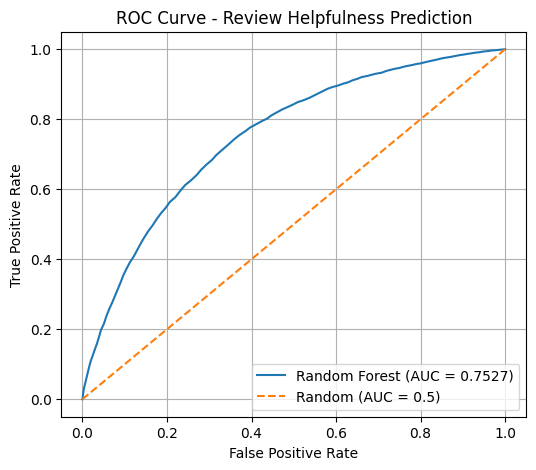

In [16]:
train_and_evaluate(df_ready)